# EDA — Base Analítica de Alunos

## Análise Exploratória para Modelagem Supervisionada

**Objetivo:** Compreender o comportamento da base analítica no grão aluno antes da construção da pipeline de Machine Learning. Esta análise fundamenta as decisões de definição de universo, seleção de variáveis e tratamento de vazamento aplicadas na modelagem.

**O que este notebook NÃO faz:**
- Treinamento de modelos (responsabilidade de `02_modelagem.ipynb`)
- Imputação, encoding ou qualquer transformação persistida (ocorre dentro da pipeline do modelo)
- Construção ou limpeza da base (etapa anterior, sobre a camada Gold da Fase 2)

**O que este notebook entrega:**
1. Perfil dimensional da base e diagnóstico de valores nulos
2. Definição e justificativa do universo de modelagem
3. Demonstração empírica das duas fontes de data leakage
4. Distribuições das variáveis numéricas e da variável alvo
5. Relação entre o alvo e os contextos escolar, territorial e socioeconômico
6. Confronto entre resultado observado e meta pactuada
7. Identificação dos municípios em maior risco educacional
8. Agrupamento de municípios por perfil, respondendo à pergunta sobre padrões regionais
9. Tabela de achados e hipóteses para a modelagem

## 1. Setup e Configuração

O corte de 743 pontos é o parâmetro oficial da Pesquisa Alfabetiza Brasil que define a variável alvo. `ANO_MODELAGEM` e `ANO_HISTORICO` separam o ano previsto do ano usado como histórico, distinção que sustenta o tratamento de vazamento temporal da seção 4.

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

CAMINHO_BASE = "../data/base_gold_alunos.parquet"
CAMINHO_IMAGENS = "../images"
CORTE_ALFABETIZACAO = 743
ANO_HISTORICO = 2023
ANO_MODELAGEM = 2024
SEMENTE = 42

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carregamento e Perfil Dimensional

Leitura da base completa e visão geral de escala, tipos e ocupação de memória.

In [48]:
base = pd.read_parquet(CAMINHO_BASE)
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 45 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   ano                                     int16  
 1   id_municipio                            int32  
 2   id_escola                               int32  
 3   id_aluno                                int32  
 4   caderno                                 int8   
 5   serie                                   int8   
 6   rede                                    int8   
 7   presenca                                int8   
 8   preenchimento_caderno                   int8   
 9   alfabetizado                            int8   
 10  proficiencia                            float32
 11  peso_aluno                              float32
 12  rede_nome                               str    
 13  taxa_alfabetizacao_escola_historica     float32
 14  alunos_avaliados_escola_historica       float

In [49]:
base.head()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,rede_nome,taxa_alfabetizacao_escola_historica,alunos_avaliados_escola_historica,taxa_alfabetizacao_municipio_historica,media_portugues_municipio_historica,meta_alfabetizacao_municipio,percentual_participacao_municipio,razao_dependencia,expectativa_anos_estudo,taxa_analfabetismo_18_mais,taxa_atraso_0_fundamental,taxa_freq_liquida_fundamental,indice_gini,prop_pobreza_criancas,renda_pc,taxa_agua_esgoto_inadequados,taxa_criancas_dom_sem_fund,taxa_criancas_fora_escola_6_14,taxa_mulheres_chefe_filho_15m,populacao,populacao_urbana,populacao_rural,idhm,idhm_e,idhm_r,nome_municipio,codigo_uf,sigla_uf,nome_uf,regiao,meta_alfabetizacao_uf,percentual_participacao_uf,meta_alfabetizacao_brasil
0,2023,1100015,60000156,11019574,8,2,3,0,0,0,NaN,NaN,Municipal,0.00,4.00,64.55,758.33,NaN,89.37,47.37,8.67,13.00,63.21,92.88,0.58,37.33,476.99,9.31,45.73,4.32,14.51,24392.00,13970.00,10422.00,0.64,0.53,0.66,Alta Floresta D'Oeste,11,RO,Rondônia,Norte,NaN,88.10,NaN
1,2023,1100015,60000156,11019583,8,2,3,0,0,0,NaN,NaN,Municipal,0.00,4.00,64.55,758.33,NaN,89.37,47.37,8.67,13.00,63.21,92.88,0.58,37.33,476.99,9.31,45.73,4.32,14.51,24392.00,13970.00,10422.00,0.64,0.53,0.66,Alta Floresta D'Oeste,11,RO,Rondônia,Norte,NaN,88.10,NaN
2,2023,1100015,60000156,11019582,8,2,3,0,0,0,NaN,NaN,Municipal,0.00,4.00,64.55,758.33,NaN,89.37,47.37,8.67,13.00,63.21,92.88,0.58,37.33,476.99,9.31,45.73,4.32,14.51,24392.00,13970.00,10422.00,0.64,0.53,0.66,Alta Floresta D'Oeste,11,RO,Rondônia,Norte,NaN,88.10,NaN
3,2023,1100015,60000156,11019571,8,2,3,0,0,0,NaN,NaN,Municipal,0.00,4.00,64.55,758.33,NaN,89.37,47.37,8.67,13.00,63.21,92.88,0.58,37.33,476.99,9.31,45.73,4.32,14.51,24392.00,13970.00,10422.00,0.64,0.53,0.66,Alta Floresta D'Oeste,11,RO,Rondônia,Norte,NaN,88.10,NaN
4,2023,1100015,60000156,11019569,8,2,3,1,1,0,679.70,4.00,Municipal,0.00,4.00,64.55,758.33,NaN,89.37,47.37,8.67,13.00,63.21,92.88,0.58,37.33,476.99,9.31,45.73,4.32,14.51,24392.00,13970.00,10422.00,0.64,0.53,0.66,Alta Floresta D'Oeste,11,RO,Rondônia,Norte,NaN,88.10,NaN


## 3. Universo de Modelagem

Dois filtros definem o universo, cada um por um motivo diferente.

**Alunos efetivamente avaliados.** Ausentes e quem compareceu sem preencher o caderno recebem `alfabetizado = 0` por convenção administrativa, sem que tenha havido medição de aprendizagem.

**Apenas o ano de 2024.** As features de contexto histórico foram calculadas sobre 2023. Aplicá-las a alunos de 2023 significaria descrever o aluno com um agregado que o contém. A seção 4 demonstra o efeito.

In [50]:
print("=" * 60)
print("  PRESENÇA VERSUS RÓTULO")
print("=" * 60)
print()
print(pd.crosstab(base["presenca"], base["alfabetizado"], margins=True))

  PRESENÇA VERSUS RÓTULO

alfabetizado        0        1      All
presenca                               
0              512153        0   512153
1             1371300  1984546  3355846
All           1883453  1984546  3867999


Nenhum aluno ausente recebe rótulo 1. O rótulo dos ausentes mede ausência, não alfabetização.

In [51]:
avaliados = base[(base["presenca"] == 1) & (base["preenchimento_caderno"] == 1)].copy()
universo = avaliados[avaliados["ano"] == ANO_MODELAGEM].copy()

print("=" * 60)
print("  UNIVERSO DE MODELAGEM")
print("=" * 60)
print(f"\nBase completa:            {len(base):>12,}")
print(f"Avaliados (ambos anos):   {len(avaliados):>12,}")
print(f"Universo ({ANO_MODELAGEM}):          {len(universo):>12,}")
print(f"Proporção da base:        {len(universo) / len(base):>12.1%}")

  UNIVERSO DE MODELAGEM

Base completa:               3,867,999
Avaliados (ambos anos):      3,354,661
Universo (2024):             1,851,852
Proporção da base:               47.9%


## 4. Data Leakage

Duas fontes de vazamento foram identificadas na base. Ambas são demonstradas empiricamente antes de qualquer decisão de exclusão.

### 4.1 A proficiência determina o alvo

`alfabetizado` deriva de `proficiencia` pelo corte de 743 pontos. Como feature, o modelo não aprenderia nada sobre alfabetização, apenas reaprenderia uma regra aritmética.

In [52]:
print("=" * 60)
print("  PROFICIÊNCIA POR RÓTULO")
print("=" * 60)
print()
print(universo.groupby("alfabetizado")["proficiencia"].agg(["count", "min", "max", "mean"]))

acuracia = ((universo["proficiencia"] >= CORTE_ALFABETIZACAO).astype(int) == universo["alfabetizado"]).mean()
print(f"\nAcurácia usando apenas o corte de {CORTE_ALFABETIZACAO}: {acuracia:.6f}")

  PROFICIÊNCIA POR RÓTULO

                count    min    max   mean
alfabetizado                              
0              744733 593.88 743.00 703.22
1             1107119 743.00 900.89 779.87

Acurácia usando apenas o corte de 743: 1.000000


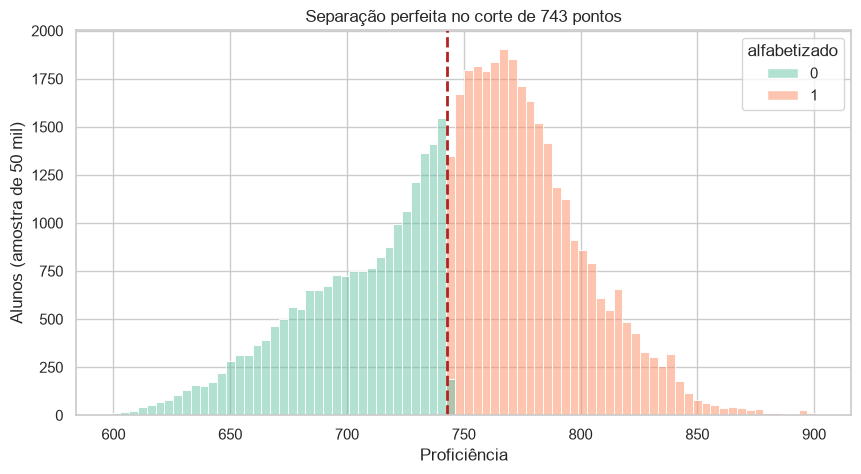

In [53]:
amostra = universo.sample(50_000, random_state=SEMENTE)

eixo = sns.histplot(data=amostra, x="proficiencia", hue="alfabetizado", bins=80, palette="Set2")
eixo.axvline(CORTE_ALFABETIZACAO, color="firebrick", linestyle="--", linewidth=2)
eixo.set_title(f"Separação perfeita no corte de {CORTE_ALFABETIZACAO} pontos")
eixo.set_xlabel("Proficiência")
eixo.set_ylabel("Alunos (amostra de 50 mil)")
plt.savefig(f"{CAMINHO_IMAGENS}/leakage_proficiencia.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Vazamento temporal nas features de contexto

As taxas históricas foram calculadas sobre os alunos de 2023. Para um aluno de 2023, essa taxa inclui o próprio resultado dele; para um aluno de 2024, foi medida sobre outra coorte, já que a base é toda de 2º ano.

A comparação abaixo mede a correlação nos dois anos. A diferença é o tamanho do vazamento.

In [54]:
print("=" * 60)
print("  CORRELAÇÃO DA TAXA HISTÓRICA DA ESCOLA COM O ALVO")
print("=" * 60)
print()
for ano, grupo in avaliados.groupby("ano"):
    correlacao = grupo["taxa_alfabetizacao_escola_historica"].corr(grupo["alfabetizado"])
    marcador = "contaminado" if ano == ANO_HISTORICO else "limpo"
    print(f"  {ano}: {correlacao:.4f}  ({marcador})")

  CORRELAÇÃO DA TAXA HISTÓRICA DA ESCOLA COM O ALVO

  2023: 0.4321  (contaminado)
  2024: 0.1003  (limpo)


**Decisão:** o universo fica restrito a 2024. Saem das features `proficiencia`, `presenca`, `preenchimento_caderno` (constantes após o filtro), `serie` (constante) e `caderno` (aleatório por desenho amostral).

## 5. Distribuição da Variável Alvo

Verifica o balanceamento entre as classes, que determina se são necessárias técnicas de reamostragem ou ponderação.

In [55]:
print("=" * 60)
print("  BALANCEAMENTO DO ALVO")
print("=" * 60)
print()
print(universo["alfabetizado"].value_counts(normalize=True).mul(100).round(2))
print(f"\nTaxa nacional em {ANO_MODELAGEM}: {universo['alfabetizado'].mean():.2%}")

  BALANCEAMENTO DO ALVO

alfabetizado
1   59.78
0   40.22
Name: proportion, dtype: float64

Taxa nacional em 2024: 59.78%


## 6. Distribuição das Variáveis Numéricas

Avalia forma, escala e assimetria das preditoras. Variáveis em escalas muito diferentes ou com cauda longa orientam a escolha do transformador numérico da pipeline.

In [56]:
COLUNAS_NUMERICAS = [
    "taxa_alfabetizacao_escola_historica",
    "alunos_avaliados_escola_historica",
    "taxa_alfabetizacao_municipio_historica",
    "idhm",
    "renda_pc",
    "indice_gini",
    "taxa_criancas_dom_sem_fund",
    "taxa_atraso_0_fundamental",
    "populacao",
]

universo[COLUNAS_NUMERICAS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
taxa_alfabetizacao_escola_historica,1462400.00,58.08,23.44,0.00,41.67,59.09,75.56,100.00
alunos_avaliados_escola_historica,1462400.00,43.04,32.33,1.00,19.00,35.00,57.00,388.00
taxa_alfabetizacao_municipio_historica,1816270.00,56.63,15.55,3.41,46.69,56.19,65.95,100.00
idhm,1851210.00,0.71,0.08,0.42,0.67,0.73,0.77,0.86
renda_pc,1851210.00,754.20,399.58,96.25,448.89,699.41,951.17,2043.74
indice_gini,1851210.00,0.53,0.07,0.28,0.48,0.52,0.58,0.80
taxa_criancas_dom_sem_fund,1851210.00,29.35,13.29,6.35,18.25,25.25,37.31,80.91
taxa_atraso_0_fundamental,1851210.00,66.78,9.76,25.92,60.48,67.77,74.98,95.41
populacao,1851210.00,1022626.62,2598622.00,805.00,27359.00,101262.00,428527.00,11253503.00


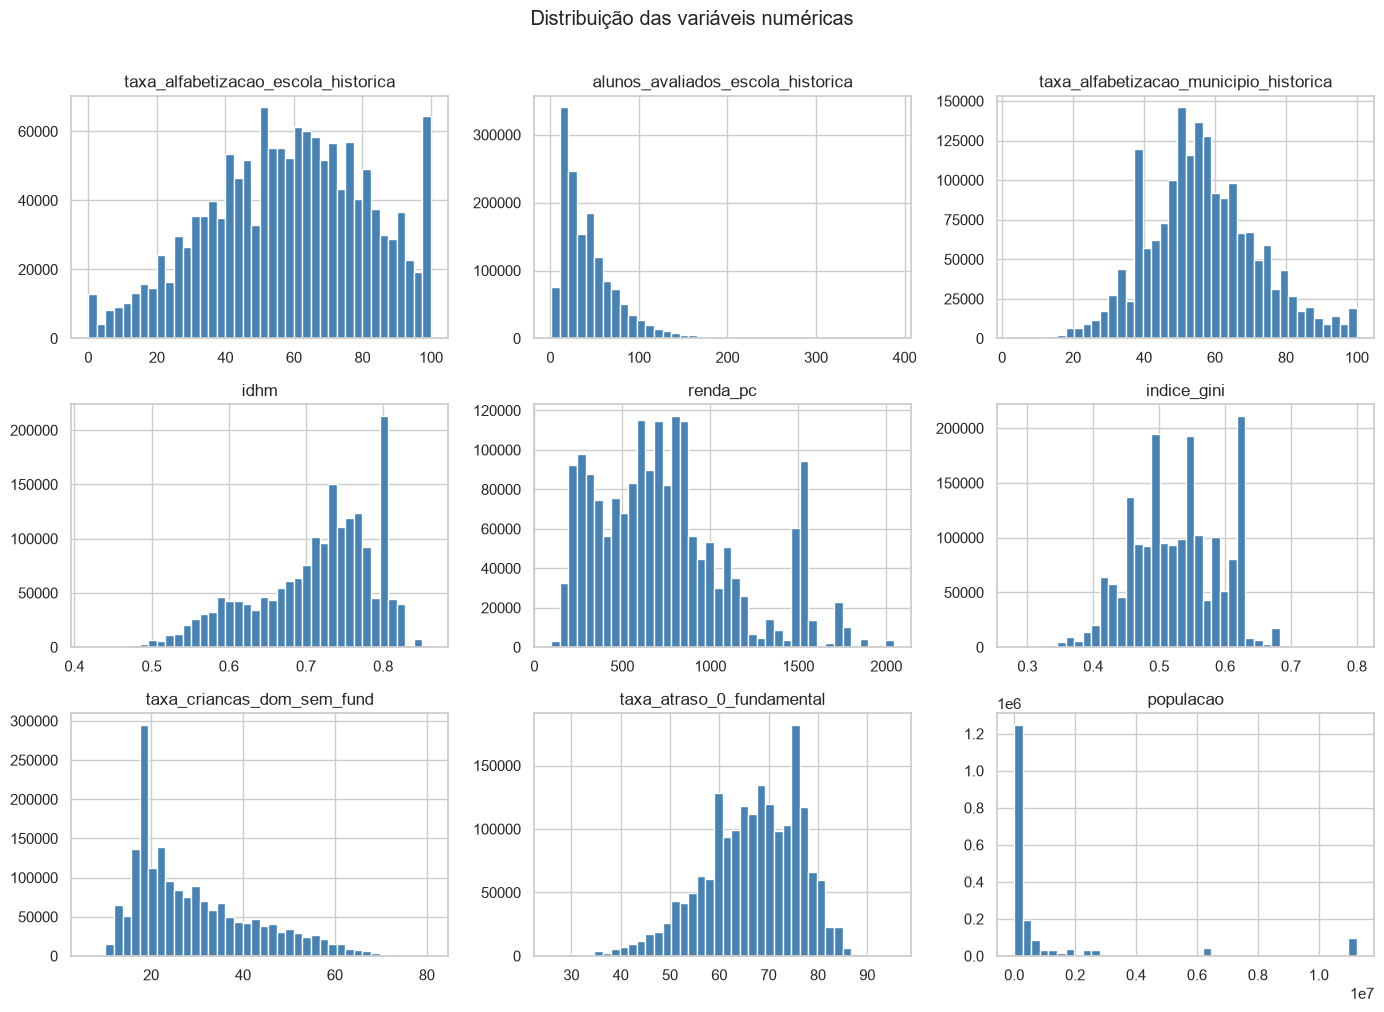

In [57]:
eixos = universo[COLUNAS_NUMERICAS].hist(bins=40, figsize=(14, 10), color="steelblue")
plt.suptitle("Distribuição das variáveis numéricas", y=1.01)
plt.tight_layout()
plt.savefig(f"{CAMINHO_IMAGENS}/distribuicoes_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Diagnóstico de Valores Nulos

A causa de cada nulo importa mais que o percentual: ausência estrutural pede imputação, enquanto ausência sistemática pode inviabilizar a variável como feature.

In [58]:
nulos = universo.isna().mean().mul(100).round(2)

print("=" * 60)
print("  VALORES NULOS NO UNIVERSO MODELADO")
print("=" * 60)
print()
print(nulos[nulos > 0].sort_values(ascending=False).to_string())

  VALORES NULOS NO UNIVERSO MODELADO

taxa_alfabetizacao_escola_historica      21.03
alunos_avaliados_escola_historica        21.03
meta_alfabetizacao_municipio             15.30
percentual_participacao_municipio        14.21
taxa_alfabetizacao_municipio_historica    1.92
media_portugues_municipio_historica       1.92
meta_alfabetizacao_uf                     1.75
expectativa_anos_estudo                   0.03
razao_dependencia                         0.03
taxa_analfabetismo_18_mais                0.03
taxa_atraso_0_fundamental                 0.03
indice_gini                               0.03
taxa_freq_liquida_fundamental             0.03
renda_pc                                  0.03
taxa_agua_esgoto_inadequados              0.03
taxa_criancas_dom_sem_fund                0.03
prop_pobreza_criancas                     0.03
taxa_criancas_fora_escola_6_14            0.03
taxa_mulheres_chefe_filho_15m             0.03
populacao_urbana                          0.03
populacao             

## 8. Relação com o Alvo: Rede e Território

A base não traz atributos individuais da criança além da rede de ensino. As relações relevantes são, portanto, contextuais.

In [59]:
print("=" * 60)
print("  TAXA DE ALFABETIZAÇÃO POR REDE")
print("=" * 60)
print()
print(universo.groupby("rede_nome")["alfabetizado"].agg(["mean", "size"]).sort_values("mean"))

  TAXA DE ALFABETIZAÇÃO POR REDE

           mean     size
rede_nome               
Municipal  0.59  1610754
Estadual   0.63   241074
Privada    0.67       24


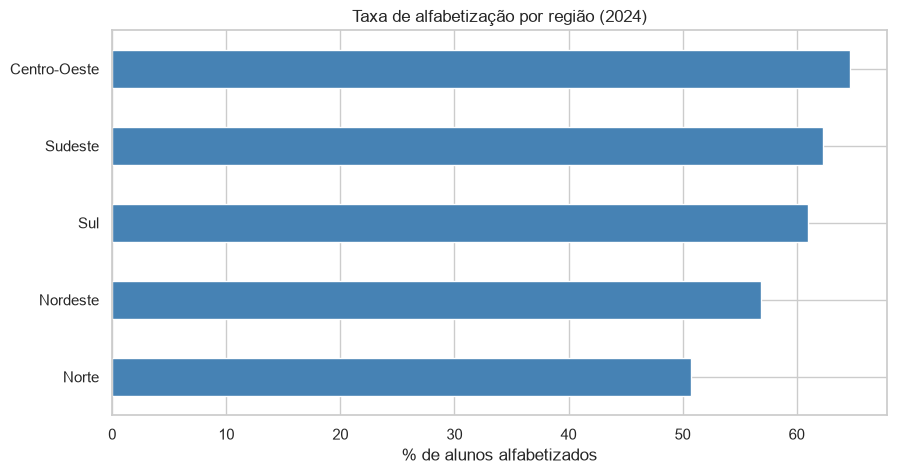

In [60]:
eixo = universo.groupby("regiao")["alfabetizado"].mean().mul(100).sort_values().plot(kind="barh", color="steelblue")
eixo.set_title(f"Taxa de alfabetização por região ({ANO_MODELAGEM})")
eixo.set_xlabel("% de alunos alfabetizados")
eixo.set_ylabel("")
plt.savefig(f"{CAMINHO_IMAGENS}/taxa_por_regiao.png", dpi=150, bbox_inches="tight")
plt.show()

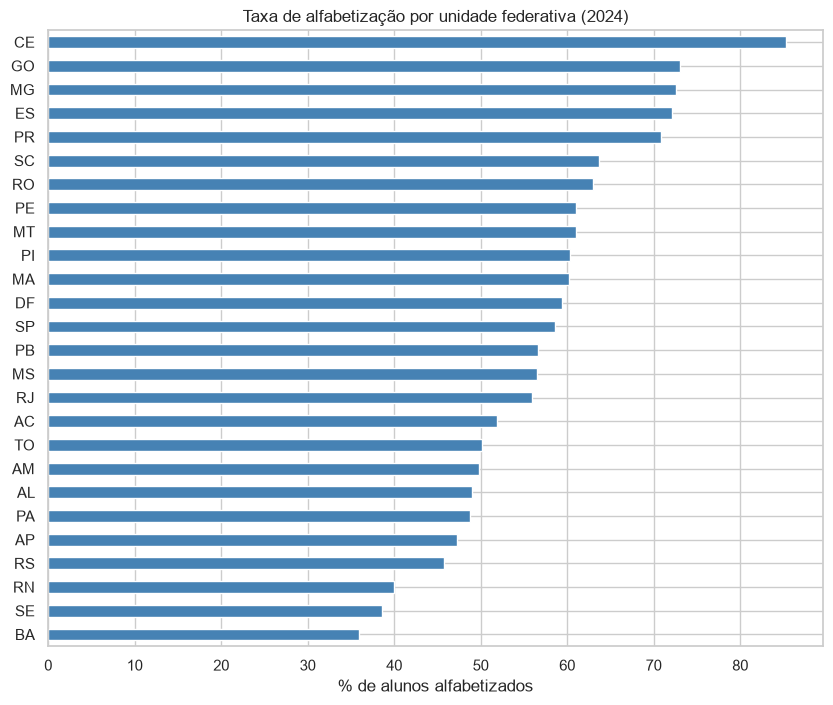

In [61]:
eixo = universo.groupby("sigla_uf")["alfabetizado"].mean().mul(100).sort_values().plot(
    kind="barh", figsize=(10, 8), color="steelblue"
)
eixo.set_title(f"Taxa de alfabetização por unidade federativa ({ANO_MODELAGEM})")
eixo.set_xlabel("% de alunos alfabetizados")
eixo.set_ylabel("")
plt.savefig(f"{CAMINHO_IMAGENS}/taxa_por_uf.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Relação com o Histórico da Escola

A taxa de alfabetização da escola em 2023 é a variável contextual mais próxima do aluno. A tabela corta o histórico em dez faixas: uma progressão monótona indica que a variável carrega sinal.

In [62]:
faixas = pd.cut(universo["taxa_alfabetizacao_escola_historica"], bins=10)

print("=" * 60)
print("  TAXA OBSERVADA POR FAIXA DE HISTÓRICO DA ESCOLA")
print("=" * 60)
print()
print(universo.groupby(faixas, observed=True)["alfabetizado"].agg(["mean", "size"]))

  TAXA OBSERVADA POR FAIXA DE HISTÓRICO DA ESCOLA

                                     mean    size
taxa_alfabetizacao_escola_historica              
(-0.1, 10.0]                         0.50   36795
(10.0, 20.0]                         0.51   58958
(20.0, 30.0]                         0.53   95138
(30.0, 40.0]                         0.56  155370
(40.0, 50.0]                         0.57  202041
(50.0, 60.0]                         0.60  212714
(60.0, 70.0]                         0.61  224810
(70.0, 80.0]                         0.63  200651
(80.0, 90.0]                         0.64  139479
(90.0, 100.0]                        0.71  136444


## 10. Relação com Indicadores Socioeconômicos

Divide os municípios em quintis de IDHM e mede a taxa em cada um. Responde à pergunta de negócio sobre quais fatores impactam a alfabetização.

In [63]:
print("=" * 60)
print("  TAXA DE ALFABETIZAÇÃO POR QUINTIL DE IDHM")
print("=" * 60)
print()
print(universo.groupby(pd.qcut(universo["idhm"], 5), observed=True)["alfabetizado"].mean().mul(100).round(2))

  TAXA DE ALFABETIZAÇÃO POR QUINTIL DE IDHM

idhm
(0.417, 0.642]   56.81
(0.642, 0.712]   60.98
(0.712, 0.747]   60.03
(0.747, 0.783]   60.77
(0.783, 0.862]   60.37
Name: alfabetizado, dtype: float64


## 11. Correlações entre Variáveis Contextuais

Além da relação de cada variável com o alvo, interessa a correlação entre elas: variáveis muito correlacionadas dividem a importância atribuída pelo SHAP e dificultam a interpretação.

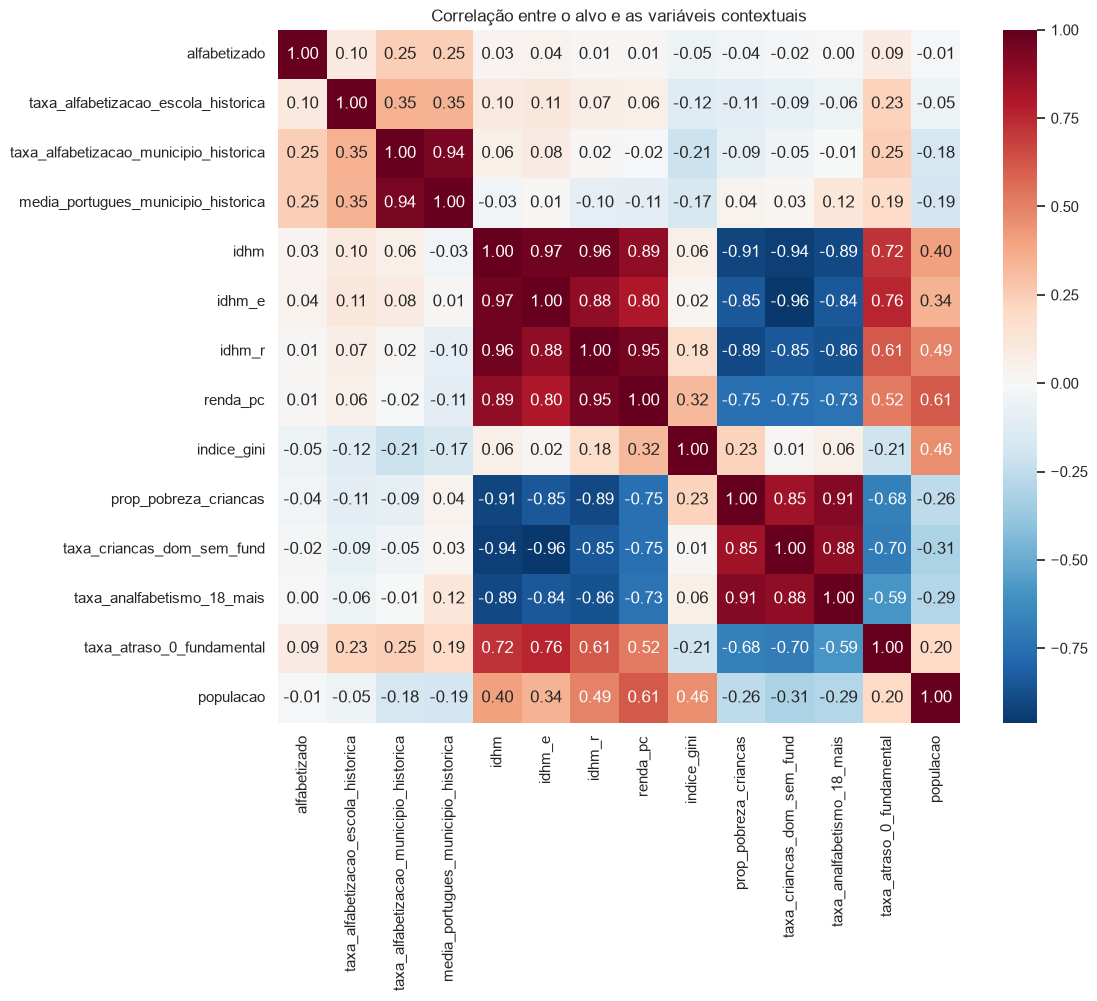

In [64]:
COLUNAS_CORRELACAO = [
    "alfabetizado",
    "taxa_alfabetizacao_escola_historica",
    "taxa_alfabetizacao_municipio_historica",
    "media_portugues_municipio_historica",
    "idhm",
    "idhm_e",
    "idhm_r",
    "renda_pc",
    "indice_gini",
    "prop_pobreza_criancas",
    "taxa_criancas_dom_sem_fund",
    "taxa_analfabetismo_18_mais",
    "taxa_atraso_0_fundamental",
    "populacao",
]

correlacoes = universo[COLUNAS_CORRELACAO].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlação entre o alvo e as variáveis contextuais")
plt.savefig(f"{CAMINHO_IMAGENS}/correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

In [65]:
print("=" * 60)
print("  CORRELAÇÃO COM A VARIÁVEL ALVO")
print("=" * 60)
print()
print(correlacoes["alfabetizado"].drop("alfabetizado").sort_values(ascending=False).to_string())

  CORRELAÇÃO COM A VARIÁVEL ALVO

media_portugues_municipio_historica       0.25
taxa_alfabetizacao_municipio_historica    0.25
taxa_alfabetizacao_escola_historica       0.10
taxa_atraso_0_fundamental                 0.09
idhm_e                                    0.04
idhm                                      0.03
idhm_r                                    0.01
renda_pc                                  0.01
taxa_analfabetismo_18_mais                0.00
populacao                                -0.01
taxa_criancas_dom_sem_fund               -0.02
prop_pobreza_criancas                    -0.04
indice_gini                              -0.05


## 12. Resultado Observado versus Meta Pactuada

Cada município tem meta anual pactuada no Compromisso Nacional Criança Alfabetizada. Esta seção mede quantos atingiram a meta de 2024, insumo direto para a pergunta de negócio sobre prever quem não alcançará metas futuras.

In [66]:
municipios = (
    universo.groupby(["id_municipio", "nome_municipio", "sigla_uf", "regiao"], observed=True)
    .agg(
        taxa_observada=("alfabetizado", "mean"),
        alunos=("alfabetizado", "size"),
        meta=("meta_alfabetizacao_municipio", "first"),
        idhm=("idhm", "first"),
    )
    .reset_index()
)
municipios["taxa_observada"] *= 100
municipios["distancia_meta"] = municipios["taxa_observada"] - municipios["meta"]

com_meta = municipios.dropna(subset=["meta"])

print("=" * 60)
print("  ATINGIMENTO DA META MUNICIPAL")
print("=" * 60)
print(f"\nMunicípios no universo:        {len(municipios):>8,}")
print(f"Com meta pactuada disponível:  {len(com_meta):>8,}")
print(f"Atingiram a meta:              {(com_meta['distancia_meta'] >= 0).sum():>8,} ({(com_meta['distancia_meta'] >= 0).mean():.1%})")
print(f"Abaixo da meta:                {(com_meta['distancia_meta'] < 0).sum():>8,} ({(com_meta['distancia_meta'] < 0).mean():.1%})")

  ATINGIMENTO DA META MUNICIPAL

Municípios no universo:           5,517
Com meta pactuada disponível:     5,232
Atingiram a meta:                 2,845 (54.4%)
Abaixo da meta:                   2,387 (45.6%)


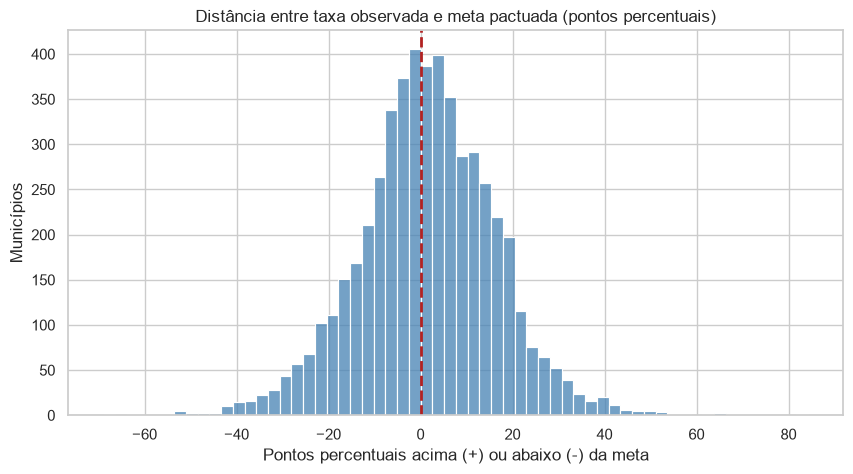

In [67]:
eixo = sns.histplot(com_meta["distancia_meta"], bins=60, color="steelblue")
eixo.axvline(0, color="firebrick", linestyle="--", linewidth=2)
eixo.set_title("Distância entre taxa observada e meta pactuada (pontos percentuais)")
eixo.set_xlabel("Pontos percentuais acima (+) ou abaixo (-) da meta")
eixo.set_ylabel("Municípios")
plt.savefig(f"{CAMINHO_IMAGENS}/distancia_meta.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Municípios em Maior Risco Educacional

Responde à pergunta de negócio sobre onde o risco se concentra. O recorte exige um mínimo de alunos avaliados: com poucos alunos, a taxa oscila por acaso e não indica risco real.

In [68]:
MINIMO_ALUNOS = 100

criticos = municipios[municipios["alunos"] >= MINIMO_ALUNOS].nsmallest(15, "taxa_observada")

print("=" * 60)
print(f"  15 MUNICÍPIOS COM MENOR TAXA (mínimo de {MINIMO_ALUNOS} alunos)")
print("=" * 60)
print()
print(criticos[["nome_municipio", "sigla_uf", "taxa_observada", "alunos", "meta", "idhm"]].to_string(index=False))

  15 MUNICÍPIOS COM MENOR TAXA (mínimo de 100 alunos)

  nome_municipio sigla_uf  taxa_observada  alunos  meta  idhm
 Ilha das Flores       SE           15.79     114 34.17  0.56
      Carmópolis       SE           16.33     147 32.07  0.64
           Aporá       BA           16.52     230 24.70  0.55
  Porto da Folha       SE           17.54     228 30.74  0.57
     Várzea Nova       BA           17.95     156 39.73  0.56
           Abaré       BA           18.24     159 35.44  0.57
          Uarini       AM           19.10     199 19.75  0.53
           Amapá       AP           19.64     112 38.23  0.64
        Serrinha       BA           19.92     487 32.42  0.63
Presidente Dutra       BA           20.00     100 28.43  0.61
 Pedro Alexandre       BA           20.45     132 36.27  0.51
       Casa Nova       BA           20.93     430 19.44  0.57
          Itiúba       BA           21.05     247 34.97  0.54
        Olindina       BA           21.29     202 41.30  0.56
Coração de Mari

In [69]:
print("=" * 60)
print("  CONCENTRAÇÃO DO RISCO POR REGIÃO")
print("=" * 60)
print()
print(
    municipios[municipios["alunos"] >= MINIMO_ALUNOS]
    .assign(risco=lambda d: d["taxa_observada"] < 40)
    .groupby("regiao", observed=True)["risco"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "municipios_abaixo_40", "mean": "proporcao"})
    .sort_values("proporcao", ascending=False)
)

  CONCENTRAÇÃO DO RISCO POR REGIÃO

              municipios_abaixo_40  proporcao
regiao                                       
Nordeste                       294       0.28
Norte                           65       0.22
Sul                             21       0.04
Centro-Oeste                     8       0.03
Sudeste                         11       0.01


## 14. Padrões Regionais

Agrupa municípios por perfil socioeconômico e educacional, respondendo à pergunta de negócio sobre quais regiões apresentam padrões semelhantes. A clusterização é exploratória e não alimenta o modelo supervisionado.

Quatro clusters por legibilidade: perfis demais tornam a leitura para gestão pública pouco acionável.

In [70]:
COLUNAS_PERFIL = [
    "idhm",
    "renda_pc",
    "indice_gini",
    "prop_pobreza_criancas",
    "taxa_criancas_dom_sem_fund",
    "taxa_alfabetizacao_municipio_historica",
]

perfil = (
    universo.groupby(["id_municipio", "regiao"], observed=True)[COLUNAS_PERFIL + ["alfabetizado"]]
    .mean()
    .dropna()
    .reset_index()
)

perfil["cluster"] = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10).fit_predict(
    StandardScaler().fit_transform(perfil[COLUNAS_PERFIL])
)

print("=" * 60)
print(f"  PERFIL MÉDIO DOS CLUSTERS ({len(perfil):,} municípios)")
print("=" * 60)
print()
print(perfil.groupby("cluster")[COLUNAS_PERFIL + ["alfabetizado"]].mean().round(3))

  PERFIL MÉDIO DOS CLUSTERS (5,470 municípios)

         idhm  renda_pc  indice_gini  prop_pobreza_criancas  \
cluster                                                       
0        0.68    520.14         0.48                  25.37   
1        0.74    769.86         0.46                   9.87   
2        0.58    270.45         0.54                  57.50   
3        0.59    276.88         0.52                  56.05   

         taxa_criancas_dom_sem_fund  taxa_alfabetizacao_municipio_historica  \
cluster                                                                       
0                             37.43                                   63.32   
1                             24.74                                   67.51   
2                             51.26                                   38.66   
3                             49.08                                   77.71   

         alfabetizado  
cluster                
0                0.67  
1                0.67  
2 

In [71]:
print("=" * 60)
print("  DISTRIBUIÇÃO REGIONAL DE CADA CLUSTER (%)")
print("=" * 60)
print()
print(pd.crosstab(perfil["cluster"], perfil["regiao"], normalize="index").mul(100).round(1))

  DISTRIBUIÇÃO REGIONAL DE CADA CLUSTER (%)

regiao   Centro-Oeste  Nordeste  Norte  Sudeste   Sul
cluster                                              
0               17.60      9.00   6.50    40.50 26.50
1                8.60      0.80   0.90    47.30 42.40
2                1.60     74.00  17.80     6.30  0.30
3                1.90     70.80   5.50    17.30  4.60


## 15. Conclusões e Implicações para a Modelagem

### Achados Principais

| # | Achado | Implicação para a Modelagem |
|---|---|---|
| 1 | `alfabetizado` é função determinística de `proficiencia` no corte de 743 pontos: um classificador que aplica apenas o limiar atinge acurácia 1,000000 | Remover `proficiencia` das features |
| 2 | Todos os 512.153 alunos ausentes recebem rótulo 0, sem exceção. O rótulo mede ausência, não aprendizagem | `presenca` e `preenchimento_caderno` definem o universo, não entram como features |
| 3 | A taxa histórica da escola correlaciona 0,4321 com o alvo em 2023 e 0,1003 em 2024. A diferença é o vazamento de incluir o próprio aluno no agregado | Universo restrito a 2024, com 2023 como histórico. Redução de 3,35M para 1,85M registros |
| 4 | `serie` é constante e `caderno` é aleatório por desenho amostral | Ambas removidas; `caderno` fica como controle negativo na interpretabilidade |
| 5 | O contexto municipal correlaciona mais com o alvo (0,25) que o contexto escolar (0,10), apesar de ser o grão mais distante do aluno | A mediana de 35 alunos avaliados por escola torna a taxa escolar ruidosa. `alunos_avaliados_escola_historica` entra como indicador de confiabilidade |
| 6 | `taxa_alfabetizacao_municipio_historica` e `media_portugues_municipio_historica` correlacionam 0,94 entre si; as três dimensões do IDHM correlacionam entre 0,95 e 0,97 com o índice composto | Manter um representante por bloco, para que o SHAP não divida importância entre variáveis redundantes |
| 7 | O IDHM separa apenas o quintil inferior (56,8% contra 60% a 61% nos demais) | Relação em degrau, não linear. Modelos de árvore capturam o corte; modelos lineares perdem o efeito |
| 8 | A taxa da escola em 2023 tem 21,03% de ausência em 2024, contra 1,92% do contexto municipal | Imputação obrigatória. A ausência é estrutural: escolas sem participação no ano anterior |
| 9 | Balanceamento de 59,78% contra 40,22% | Dispensa reamostragem ou ponderação de classe |
| 10 | 45,6% dos municípios ficaram abaixo da meta pactuada para 2024 | Alvo alternativo viável no grão município, e recorte natural para a aplicação estratégica |
| 11 | O risco se concentra no Nordeste (28% dos municípios abaixo de 40% de alfabetização) e no Norte (22%), contra 1% no Sudeste | Região e UF entram como features categóricas |
| 12 | Municípios com perfil socioeconômico praticamente idêntico (IDHM 0,58 e 0,59, pobreza infantil 57% e 56%) apresentam 47% e 75% de alfabetização | As variáveis do Atlas não explicam a diferença. O fator determinante está fora do que a base mede |
| 13 | A maior correlação individual com o alvo é 0,25 | Expectativa de desempenho moderado. Modelos lineares e de árvore tendem a empatar |
| 14 | Nenhum atributo individual da criança existe na base além da rede de ensino | Alunos da mesma escola recebem predição idêntica. O resultado é score de risco territorial |

### Hipóteses para a Modelagem

**H1 — O histórico educacional supera o contexto socioeconômico.** As variáveis de desempenho passado (município e escola) apresentam correlação de uma ordem de grandeza acima das socioeconômicas do Atlas. A hipótese é que o SHAP confirme essa hierarquia, indicando que a trajetória educacional recente prediz melhor que as condições estruturais medidas em 2010.

**H2 — A defasagem do Atlas limita seu poder preditivo.** As variáveis socioeconômicas referem-se ao Censo de 2010 e apresentam correlação próxima de zero com o desfecho de 2024. A hipótese é que a defasagem de catorze anos, e não a irrelevância do fenômeno, explique o resultado. O teste indireto é a comparação com `taxa_atraso_0_fundamental`, também de 2010, que mantém correlação de 0,09.

**H3 — A confiabilidade da taxa escolar modera seu efeito.** A taxa da escola é ruidosa em escolas pequenas. A hipótese é que o modelo atribua maior peso a `taxa_alfabetizacao_escola_historica` quando `alunos_avaliados_escola_historica` é alto, relação que a interpretabilidade pode verificar por interação entre as duas variáveis.